In [1]:
import logging

# Configure logging
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s - %(levelname)s - %(message)s",
                    handlers=[logging.StreamHandler()])


In [2]:
# Import required packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


2025-09-05 17:27:55,582 - INFO - NumExpr defaulting to 8 threads.


In [4]:
path = '/content/drive/MyDrive/Breast_GSE_Samples_USK476 - VAWASTHI.csv'
df = pd.read_csv('/Users/prashantdubey/Downloads/Breast_GSE_Samples_USK476 - VAWASTHI.csv')
print("Shape:", df.shape)
df.head()

Shape: (151, 54677)


,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


In [5]:
# Split the features and labels
labels = df['type']
x = df.drop(columns=['type'])
x.head()

,samples,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,8.870780,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,7.767646,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,9.417956,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,9.022345,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,9.400056,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


In [6]:
# Standardise the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [7]:
# Remove low variance genes to reduce noise
selector = VarianceThreshold(threshold=0.01)
x_filtered = selector.fit_transform(x_scaled)

In [8]:
# Split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x_filtered, labels, test_size=0.2, random_state=42, stratify=labels)

In [9]:
# Train random forest on the data
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [10]:
# Evaluate the model
y_pred = rf.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.83      0.83      0.83         6
   luminal_B       0.86      1.00      0.92         6
      normal       1.00      0.50      0.67         2

    accuracy                           0.94        31
   macro avg       0.95      0.89      0.90        31
weighted avg       0.94      0.94      0.93        31



- The classification report shows the model has a strong overall performance with an accuracy score of 94%.
- All classes except from the normal class have an f1-score of 83% or more, with strong precision and recall scores.
- The HER, basal and cell_line classes all have perfect classification, however the normal class has a recall of 50%, so 1 out of 2 normal class samples were misclassified.

Confusion Matrix:


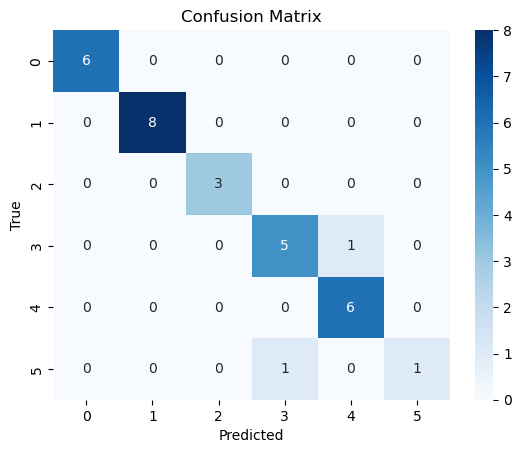

In [11]:
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

- The confusion matrix shows there were very few misclassifications
- It shows that one Normal sample was misclassified as Luminal A, possible due to similarity or lack of Normal training samples


Random Forest Accuracy: 0.9677
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       1.00      0.83      0.91         6
   luminal_B       0.86      1.00      0.92         6
      normal       1.00      1.00      1.00         2

    accuracy                           0.97        31
   macro avg       0.98      0.97      0.97        31
weighted avg       0.97      0.97      0.97        31



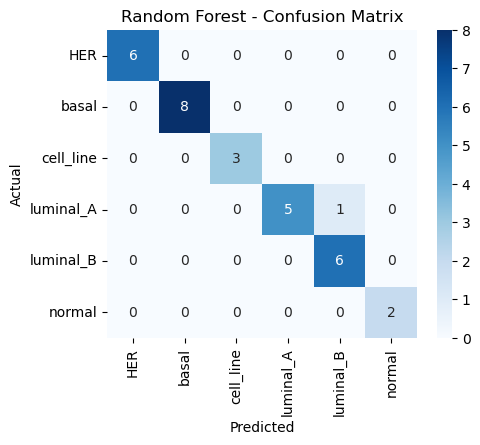


Logistic Regression Accuracy: 0.9677
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       0.89      1.00      0.94         8
   cell_line       1.00      0.67      0.80         3
   luminal_A       1.00      1.00      1.00         6
   luminal_B       1.00      1.00      1.00         6
      normal       1.00      1.00      1.00         2

    accuracy                           0.97        31
   macro avg       0.98      0.94      0.96        31
weighted avg       0.97      0.97      0.97        31



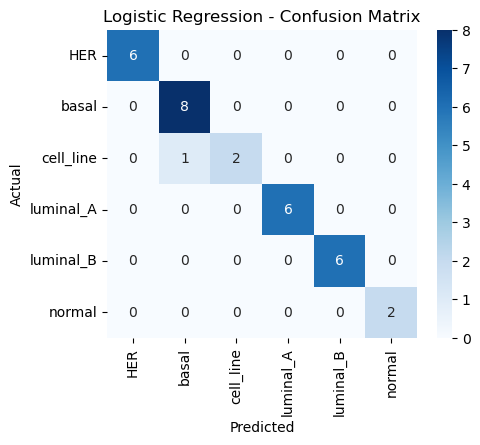


SVM (Linear) Accuracy: 1.0000
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       1.00      1.00      1.00         6
   luminal_B       1.00      1.00      1.00         6
      normal       1.00      1.00      1.00         2

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



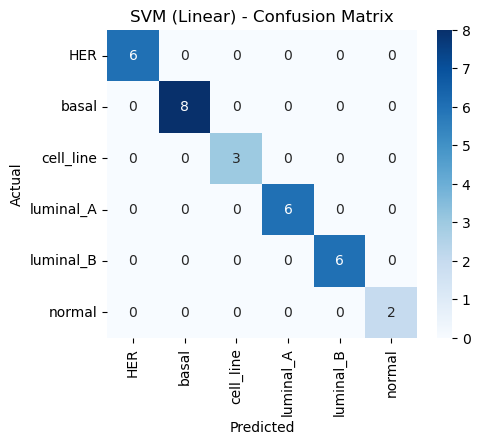

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:30:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



xGBoost Accuracy: 0.9355
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      0.88      0.93         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       1.00      0.83      0.91         6
   luminal_B       0.75      1.00      0.86         6
      normal       1.00      1.00      1.00         2

    accuracy                           0.94        31
   macro avg       0.96      0.95      0.95        31
weighted avg       0.95      0.94      0.94        31



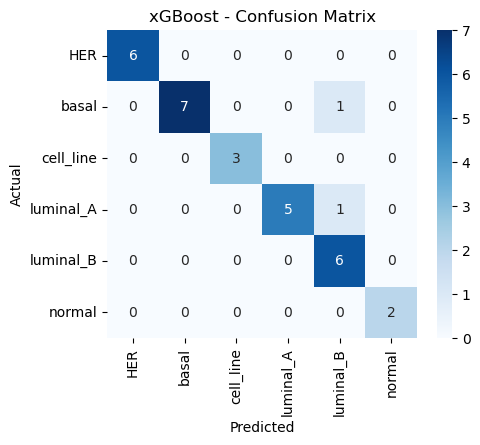

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001497 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20820
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 500
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.290984
[LightGBM] [Info] Start training from score -2.389596
[LightGBM] [Info] Start training from score -1.651998
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


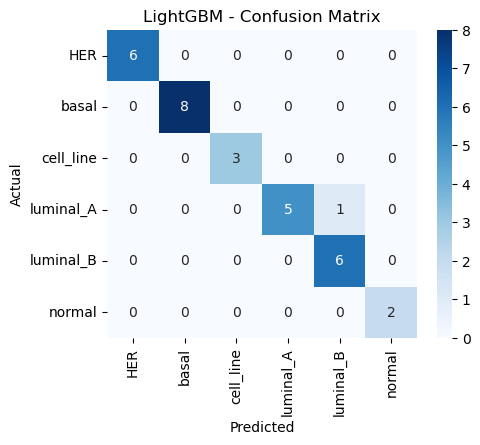

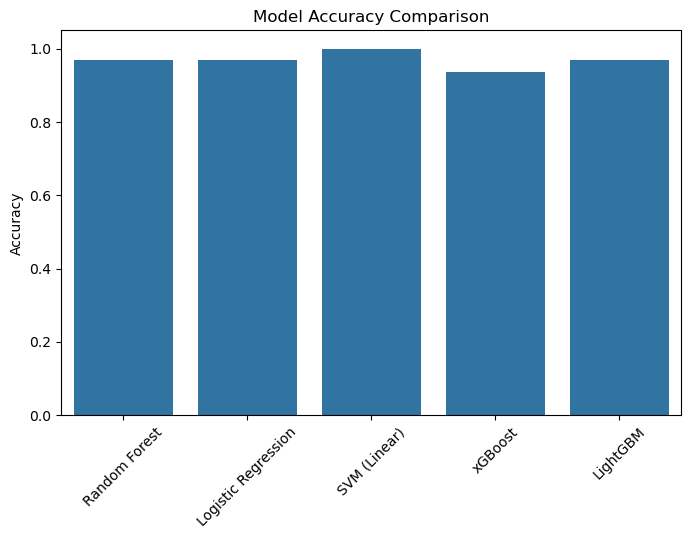

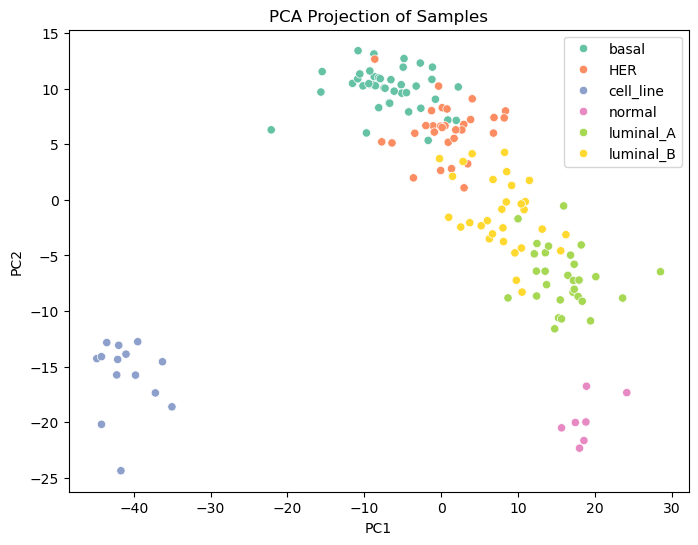

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [13]:
# ===============================
# ADVANCED BREAST CANCER MODELING PIPELINE
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb

# ----------------------

# Separate features and target
x = df.drop(columns=["samples", "type"])
y = df["type"]

# ----------------------
# Encode target labels
# ----------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ----------------------
# Feature selection (Top 500 genes by ANOVA F-test)
# ----------------------
selector = SelectKBest(score_func=f_classif, k=500)
x_selected = selector.fit_transform(x, y_encoded)

# ----------------------
# Scale features
# ----------------------
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_selected)

# ----------------------
# Train-Test Split
# ----------------------
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# ----------------------
# Models to compare
# ----------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=5000, penalty="l1", solver="liblinear"),
    "SVM (Linear)": SVC(kernel="linear", probability=True, random_state=42),
    "xGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

results = {}

# ----------------------
# Train & Evaluate Models
# ----------------------
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ----------------------
# Compare Model Accuracies
# ----------------------
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()

# ----------------------
# PCA Visualization
# ----------------------
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1],
                hue=label_encoder.inverse_transform(y_encoded),
                palette="Set2")
plt.title("PCA Projection of Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# ----------------------
# SHAP for Random Forest (Top Feature Interpretability)
# ----------------------
rf = models["Random Forest"]
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_train)

# Show SHAP summary plot for first class
shap.summary_plot(shap_values[0], x_train,
                  feature_names=np.array(x.columns)[selector.get_support()])



Extra Trees Accuracy: 1.0000
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       1.00      1.00      1.00         6
   luminal_B       1.00      1.00      1.00         6
      normal       1.00      1.00      1.00         2

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



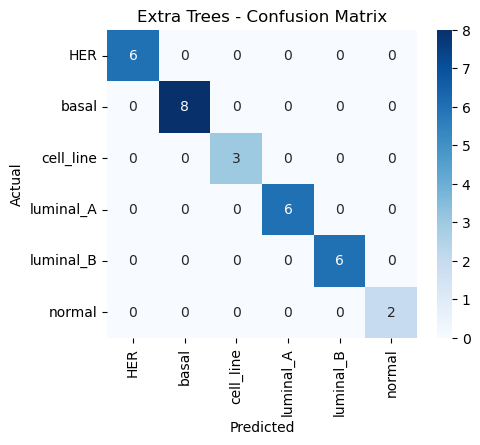


Gradient Boosting Accuracy: 0.8710
              precision    recall  f1-score   support

         HER       0.86      1.00      0.92         6
       basal       1.00      0.88      0.93         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.83      0.83      0.83         6
   luminal_B       0.67      0.67      0.67         6
      normal       1.00      1.00      1.00         2

    accuracy                           0.87        31
   macro avg       0.89      0.90      0.89        31
weighted avg       0.88      0.87      0.87        31



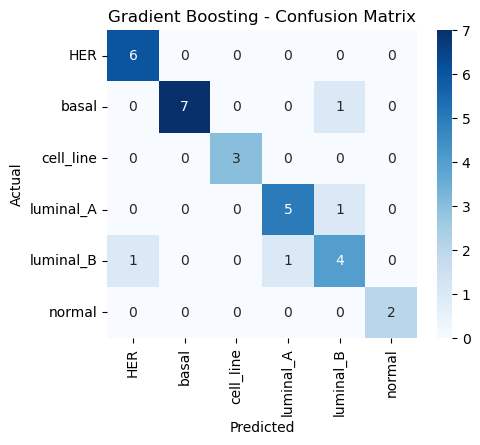


Gaussian Naive Bayes Accuracy: 0.9677
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       1.00      0.83      0.91         6
   luminal_B       0.86      1.00      0.92         6
      normal       1.00      1.00      1.00         2

    accuracy                           0.97        31
   macro avg       0.98      0.97      0.97        31
weighted avg       0.97      0.97      0.97        31



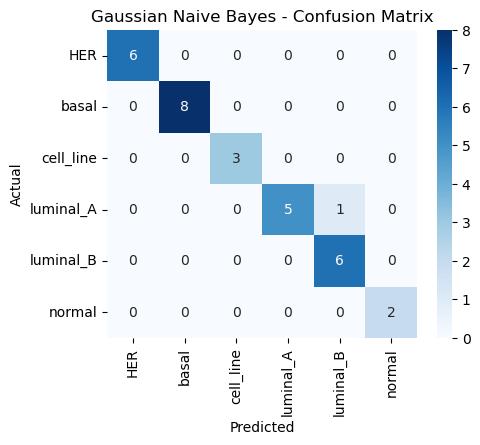


KNN (Weighted) Accuracy: 0.9677
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.86      1.00      0.92         6
   luminal_B       1.00      0.83      0.91         6
      normal       1.00      1.00      1.00         2

    accuracy                           0.97        31
   macro avg       0.98      0.97      0.97        31
weighted avg       0.97      0.97      0.97        31



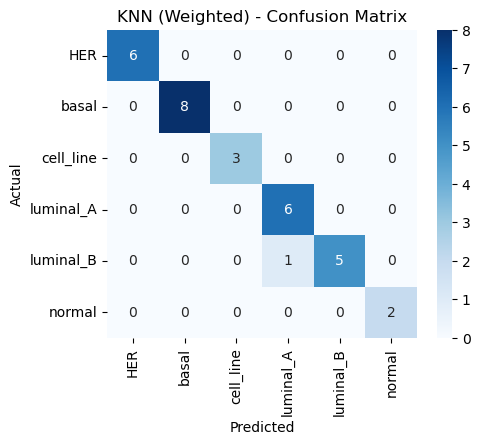


MLP Neural Net Accuracy: 1.0000
              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       1.00      1.00      1.00         6
   luminal_B       1.00      1.00      1.00         6
      normal       1.00      1.00      1.00         2

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



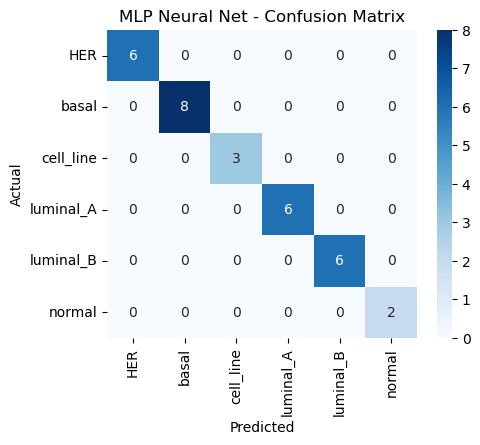

In [14]:
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Additional advanced models
advanced_models = {
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "KNN (Weighted)": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(100,),
                                    max_iter=1000,
                                    alpha=0.001,
                                    random_state=42)
}

# Train & Evaluate new models
for name, model in advanced_models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Use fewer features to reduce overfitting risk
selector = SelectKBest(score_func=f_classif, k=100)  # was 500 before

# Scale features
scaler = StandardScaler()

# Models with regularization
safe_models = {
    "Logistic Regression (L1)": LogisticRegression(max_iter=5000, penalty="l1", solver="liblinear"),
    "SVM (Linear)": SVC(kernel="linear", probability=True, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "xGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in safe_models.items():
    pipe = Pipeline([
        ('select', selector),
        ('scale', scaler),
        ('model', model)
    ])

    scores = cross_val_score(pipe, x, y_encoded, cv=cv, scoring='accuracy')
    print(f"{name} | Mean Accuracy: {scores.mean():.4f} | Std: {scores.std():.4f}")


Logistic Regression (L1) | Mean Accuracy: 0.9406 | Std: 0.0382
SVM (Linear) | Mean Accuracy: 0.9671 | Std: 0.0293
Extra Trees | Mean Accuracy: 0.9602 | Std: 0.0250


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:31:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:31:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:31:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:31:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

xGBoost | Mean Accuracy: 0.9142 | Std: 0.0491


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:31:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
import xgboost as xgb

# Define models
safe_models = {
    "Logistic Regression (L1)": LogisticRegression(max_iter=5000, penalty="l1", solver="liblinear"),
    "SVM (Linear)": SVC(kernel="linear", probability=True, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "xGBoost": xgb.xGBClassifier(eval_metric="mlogloss", random_state=42)
}

# Feature selector
selector = SelectKBest(score_func=f_classif, k=100)
scaler = StandardScaler()

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
results = []

# Loop through models
for name, model in safe_models.items():
    acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], []

    fold_idx = 1
    for train_idx, test_idx in cv.split(x, y_encoded):
        x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        pipe = Pipeline([
            ('select', selector),
            ('scale', scaler),
            ('model', model)
        ])
        pipe.fit(x_train, y_train)
        y_pred = pipe.predict(x_test)
        y_proba = pipe.predict_proba(x_test)

        # Metrics
        acc_scores.append(accuracy_score(y_test, y_pred))
        prec_scores.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        rec_scores.append(recall_score(y_test, y_pred, average='weighted'))
        f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

        # Confusion Matrix plot
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_encoder.classes_,
                    yticklabels=label_encoder.classes_)
        plt.title(f"{name} - Fold {fold_idx} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        # ROC Curve (micro-average)
        fpr, tpr, _ = roc_curve(pd.get_dummies(y_test).values.ravel(),
                                y_proba.ravel())
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC Fold {fold_idx} (AUC = {roc_auc:.2f})')
        plt.plot([0,1],[0,1],'--', color='grey')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{name} - Fold {fold_idx} ROC Curve")
        plt.legend()
        plt.show()

        # Precision-Recall Curve (micro-average)
        precision, recall, _ = precision_recall_curve(pd.get_dummies(y_test).values.ravel(),
                                                      y_proba.ravel())
        plt.figure()
        plt.plot(recall, precision, label=f'Fold {fold_idx}')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{name} - Fold {fold_idx} Precision-Recall Curve")
        plt.legend()
        plt.show()

        fold_idx += 1

    # Store aggregated metrics
    results.append({
        'Model': name,
        'Accuracy Mean': np.mean(acc_scores),
        'Accuracy Std': np.std(acc_scores),
        'Precision Mean': np.mean(prec_scores),
        'Recall Mean': np.mean(rec_scores),
        'F1 Mean': np.mean(f1_scores)
    })

# Results DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot of Accuracy
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='Model', y='Accuracy Mean', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("Cross-Validated Accuracy by Model")
plt.show()

# Bar plot of F1
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='Model', y='F1 Mean', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title("Cross-Validated F1 Score by Model")
plt.show()


AttributeError: module 'xgboost' has no attribute 'xGBClassifier'

In [18]:
!pip install shap catboost seaborn


In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# (Assuming x_train, y_train already prepared)
subtypes = pd.Series(y_train).unique()
gene_names = x_train.columns

for subtype in subtypes:
    # Binarize the task: this subtype vs all others
    y_binary = (y_train == subtype).astype(int)
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(x_train, y_binary)
    importances = clf.feature_importances_
    top_idx = np.argsort(importances)[-10:][::-1]
    print(f"\nTop Genes for subtype '{subtype}':")
    for i, idx in enumerate(top_idx):
        print(f"{i+1}. {gene_names[idx]} - Importance: {importances[idx]:.4f}")
    # Plot
    plt.figure(figsize=(6,3))
    sns.barplot(x=importances[top_idx], y=gene_names[top_idx])
    plt.title(f"Top 10 Genes for subtype: {subtype}")
    plt.xlabel("Feature Importance")
    plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
!pip install boruta
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, class_weight='balanced', random_state=42)
# Boruta expects numpy arrays
boruta_feature_selector = BorutaPy(rf, n_estimators='auto', max_iter=25, random_state=42, verbose=2)
boruta_feature_selector.fit(x_train.values, y_train)
# Get the selected features
selected_features = x_train.columns[boruta_feature_selector.support_].tolist()
print(f"Number of selected features: {len(selected_features)}")
x_train_selected = x_train[selected_features]
x_test_selected = x_test[selected_features]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.6 MB/s eta 0:00:00
Iteration: 	1 / 25
Confirmed: 	0
Tentative: 	54675
Rejected: 	0
Iteration: 	2 / 25
Confirmed: 	0
Tentative: 	54675
Rejected: 	0
Iteration: 	3 / 25
Confirmed: 	0
Tentative: 	54675
Rejected: 	0
Iteration: 	4 / 25
Confirmed: 	0
Tentative: 	54675
Rejected: 	0
Iteration: 	5 / 25
Confirmed: 	0
Tentative: 	54675
Rejected: 	0
Iteration: 	6 / 25
Confirmed: 	0
Tentative: 	54675
Rejected: 	0
Iteration: 	7 / 25
Confirmed: 	0
Tentative: 	54675
Rejected: 	0
Iteration: 	8 / 25
Confirmed: 	0
Tentative: 	7231
Rejected: 	47444
Iteration: 	9 / 25
Confirmed: 	605
Tentative: 	6626
Rejected: 	47444
Iteration: 	10 / 25
Confirmed: 	605
Tentative: 	6626
Rejected: 	47444
Iteration: 	11 / 25
Confirmed: 	605
Tentative: 	6626
Rejected: 	47444
Iteration: 	12 / 25
Confirmed: 	720
Tentative: 	4556
Rejected: 	49399
Iteration: 	13 / 25
Confirmed: 	720
Tentative: 	4556
Rejected: 	49399
Iteration: 	14 / 25
Confirmed: 	720
Tentative: 	4556
Rejec

In [ ]:
import lightgbm as lgb
from lightgbm import early_stopping
from sklearn.metrics import classification_report

gbm = lgb.LGBMClassifier(
    objective='multiclass',
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=96
)

gbm.fit(
    x_train_selected, y_train,
    eval_set=[(x_test_selected, y_test)],
    eval_metric='multi_logloss',
    callbacks=[early_stopping(stopping_rounds=20)]
)

y_pred = gbm.predict(x_test_selected)
print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34404
[LightGBM] [Info] Number of data points in the train set: 121, number of used features: 820
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
])
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto']
}
svm_search = GridSearchCV(pipe, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=2)
svm_search.fit(x_train_selected, y_train)
y_pred = svm_search.predict(x_test_selected)
print("Best SVM Params:", svm_search.best_params_)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best SVM Params: {'svc__C': 1, 'svc__gamma': 'scale'}
SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.89      1.00      0.94         8
           2       1.00      1.00      1.00         3
           3       1.00      0.83      0.91         6
           4       0.86      1.00      0.92         6
           5       1.00      1.00      1.00         1

    accuracy                           0.93        30
   macro avg       0.96      0.94      0.95        30
weighted avg       0.94      0.93      0.93        30



In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    cv=5, n_jobs=-1, verbose=2
)
stack.fit(x_train_selected, y_train)
y_pred = stack.predict(x_test_selected)
print("Stacked Model Classification Report:")
print(classification_report(y_test, y_pred))


Stacked Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.88      0.88      0.88         8
           2       1.00      0.67      0.80         3
           3       1.00      0.83      0.91         6
           4       0.86      1.00      0.92         6
           5       0.33      1.00      0.50         1

    accuracy                           0.87        30
   macro avg       0.84      0.87      0.82        30
weighted avg       0.92      0.87      0.88        30



In [ ]:
# =========================
# Step 0 — Setup & Utilities
# =========================

import os
import math
import random
import numpy as np
import pandas as pd
import warnings
import logging
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

warnings.filterwarnings("ignore")

# ----------------- Logging setup -----------------
logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger(__name__)

# ----------------- Reproducibility -----------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# ----------------- Load your dataframe -----------------
# Make sure `df` is already defined in your notebook before running this cell
# Example:
# df = pd.read_csv("your_file.csv")

assert 'df' in globals(), "Please define `df` before running."
assert 'type' in df.columns, "`df` must contain the label column 'type'."

# ----------------- Split x / y -----------------
cols_to_drop = [c for c in ['samples', 'type'] if c in df.columns]
x = df.drop(columns=cols_to_drop)
y = df['type']

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

# ----------------- Feature Selection -----------------
k_genes = min(500, x.shape[1])   # keep top 500 or fewer if dataset has less
selector = SelectKBest(score_func=f_classif, k=k_genes)
x_sel = selector.fit_transform(x, y_enc)
sel_mask = selector.get_support()
selected_gene_names = np.array(x.columns)[sel_mask]

# ----------------- Scaling -----------------
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_sel)

# ----------------- Train/Test Split -----------------
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y_enc, test_size=0.2, stratify=y_enc, random_state=RANDOM_STATE
)

# ----------------- Class Weights -----------------
classes_unique = np.unique(y_enc)
cls_weights_arr = compute_class_weight(
    class_weight='balanced', classes=classes_unique, y=y_enc
)
cls_weights = {c: w for c, w in zip(classes_unique, cls_weights_arr)}

logger.info(f"Data: x={x.shape}, Selected={x_sel.shape}, Train={x_train.shape}, Test={x_test.shape}")
logger.info(f"Classes: {dict(zip(range(len(class_names)), class_names))}")
logger.info(f"Class weights: {cls_weights}")


# ----------------- Utility function -----------------
def report_all(y_true, y_pred, y_proba=None, title="Model"):
    """
    Utility: logs classification report, confusion matrix, and ROC-AUC if available.
    """
    logger.info(f"\n===== {title} =====")
    logger.info("\n" + classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # ROC-AUC if probabilities available
    if y_proba is not None:
        try:
            macro_ovr = roc_auc_score(pd.get_dummies(y_true), y_proba,
                                      average='macro', multi_class='ovr')
            logger.info(f"Macro ROC-AUC (OvR): {macro_ovr:.4f}")
        except Exception as e:
            logger.warning(f"AUC not available: {e}")


In [ ]:
!pip install catboost lightgbm xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.4 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier, Pool


0:	learn: 0.8214896	test: 0.8070169	best: 0.8070169 (0)	total: 1.19s	remaining: 19m 48s
100:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 31.9s	remaining: 4m 43s
200:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 58.3s	remaining: 3m 51s
300:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 1m 24s	remaining: 3m 16s
400:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 1m 53s	remaining: 2m 49s
500:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 2m 19s	remaining: 2m 19s
600:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 2m 52s	remaining: 1m 54s
700:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 3m 18s	remaining: 1m 24s
800:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 3m 44s	remaining: 55.7s
900:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 4m 10s	remaining: 27.5s
999:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (5)	total: 4m 36s	remaining: 0us

bestTest = 1
bestI

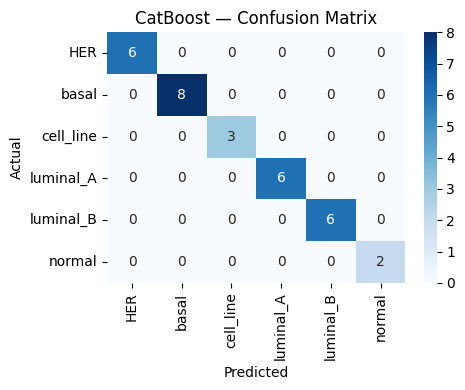

In [ ]:
# ======================================================
# Step 1 — CatBoost (ordered boosting, robust regularization)
# ======================================================
# !pip install -q catboost


from catboost import CatBoostClassifier, Pool


cat_params = dict(
iterations=1000,
learning_rate=0.03,
depth=6,
loss_function='MultiClass',
eval_metric='TotalF1:average=Weighted',
random_seed=RANDOM_STATE,
auto_class_weights='Balanced', # robust class weighting
verbose=100
)


cat_model = CatBoostClassifier(**cat_params)
train_pool = Pool(x_train, y_train)
valid_pool = Pool(x_test, y_test)
cat_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)


cat_pred = cat_model.predict(x_test).astype(int).ravel()
cat_proba = cat_model.predict_proba(x_test)
report_all(y_test, cat_pred, cat_proba, title="CatBoost")



In [ ]:
!pip install tensorflow

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step - loss: 2.0699 - val_loss: 0.9472
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 1.5417 - val_loss: 0.7561
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 1.1001 - val_loss: 0.6259
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.9134 - val_loss: 0.6760
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.7737 - val_loss: 0.8469
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.7491 - val_loss: 1.0149
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.6513 - val_loss: 1.1198
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.6190 - val_loss: 1.1601
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.5638 - val_loss: 1.1405
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.5230 - val_loss: 1.1085
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.5101 - val_loss: 1.0912
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.4847 - val_lo

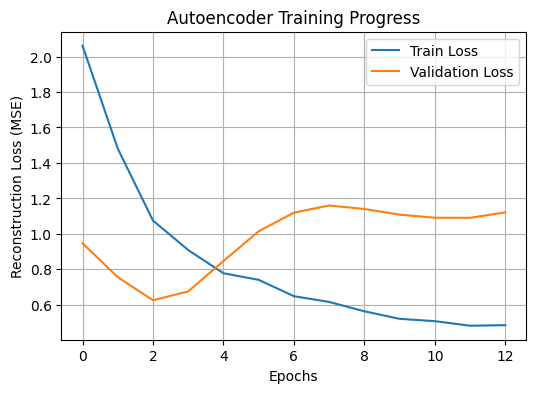

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


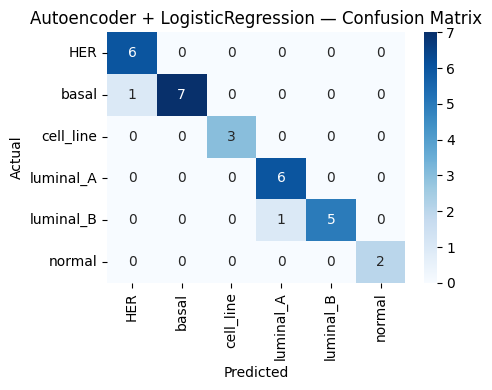

In [ ]:
# =======================================================
# Step 2 — Autoencoder + Classifier (Functional API)
# =======================================================

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, GaussianNoise, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LogisticRegression

# ----------------- Autoencoder -----------------
input_dim = x_train.shape[1]
encoding_dim = 128

inp = Input(shape=(input_dim,))
x = GaussianNoise(0.05)(inp)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
bottleneck = Dense(encoding_dim, activation='relu', name='bottleneck')(x)
x = Dense(512, activation='relu')(bottleneck)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
out = Dense(input_dim, activation='linear')(x)

ae = Model(inputs=inp, outputs=out)
ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

# ----------------- Train -----------------
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ae.fit(
    x_train, x_train,
    validation_data=(x_test, x_test),
    epochs=200,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

 #----------------- Plot Training vs Validation Loss -----------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("Autoencoder Training Progress")
plt.legend()
plt.grid(True)
plt.show()

# ----------------- Encoder model -----------------
encoder = Model(inputs=ae.input, outputs=ae.get_layer('bottleneck').output)

Z_train = encoder.predict(x_train)
Z_test  = encoder.predict(x_test)

# ----------------- Logistic Regression -----------------
clf_lr = LogisticRegression(max_iter=5000, class_weight='balanced')
clf_lr.fit(Z_train, y_train)

z_pred = clf_lr.predict(Z_test)
z_proba = clf_lr.predict_proba(Z_test)

report_all(y_test, z_pred, z_proba, title="Autoencoder + LogisticRegression")


In [ ]:
!pip install torch torchvision torchaudio


Epoch 01 | Train Loss: 1.7922 | Val Acc: 0.2581
Epoch 02 | Train Loss: 1.6242 | Val Acc: 0.2903
Epoch 03 | Train Loss: 1.5609 | Val Acc: 0.3548
Epoch 04 | Train Loss: 1.4699 | Val Acc: 0.3226
Epoch 05 | Train Loss: 1.3823 | Val Acc: 0.3548
Epoch 06 | Train Loss: 1.3075 | Val Acc: 0.3871
Epoch 07 | Train Loss: 1.2277 | Val Acc: 0.4194
Epoch 08 | Train Loss: 1.1626 | Val Acc: 0.4194
Epoch 09 | Train Loss: 1.1183 | Val Acc: 0.4839
Epoch 10 | Train Loss: 1.0771 | Val Acc: 0.4839
Epoch 11 | Train Loss: 1.0199 | Val Acc: 0.5161
Epoch 12 | Train Loss: 0.9773 | Val Acc: 0.4516
Epoch 13 | Train Loss: 0.9459 | Val Acc: 0.5484
Epoch 14 | Train Loss: 0.9368 | Val Acc: 0.6129
Epoch 15 | Train Loss: 0.8798 | Val Acc: 0.6129


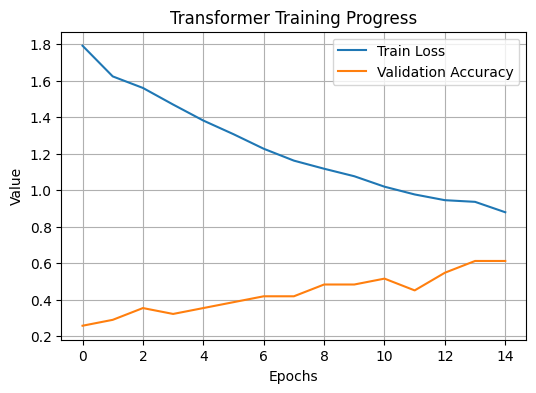

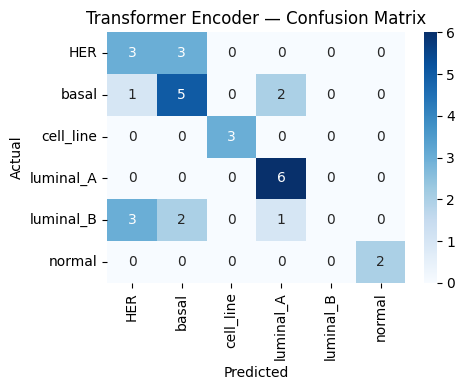

In [ ]:
# =======================================================
# Step 3 — Transformer Encoder for Gene Expression
# =======================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------- Dataset Wrapper -----------------
class GeneDataset(Dataset):
    def __init__(self, x_np, y_np=None):
        self.x = torch.tensor(x_np, dtype=torch.float32)
        self.y = None if y_np is None else torch.tensor(y_np, dtype=torch.long)
    def __len__(self): return self.x.shape[0]
    def __getitem__(self, idx):
        if self.y is None:
            return self.x[idx]
        return self.x[idx], self.y[idx]

# ----------------- Transformer Model -----------------
class GeneTransformer(nn.Module):
    def __init__(self, n_genes, n_classes, d_model=128, nhead=8, num_layers=2, dim_ff=256, dropout=0.1):
        super().__init__()
        # Learnable embedding per gene
        self.gene_embed = nn.Embedding(n_genes, d_model)
        # Project expression values to embedding space
        self.val_proj = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model, n_classes)
        )
        self.register_buffer("gene_ids", torch.arange(n_genes, dtype=torch.long))

    def forward(self, x):
        B, G = x.shape
        gid = self.gene_ids.unsqueeze(0).expand(B, -1)
        gemb = self.gene_embed(gid)               # (B,G,d)
        vemb = self.val_proj(x.unsqueeze(-1))     # (B,G,d)
        z = gemb + vemb
        z = self.encoder(z)
        z = self.norm(z)
        z = z.mean(dim=1)                         # mean pooling
        return self.classifier(z)

# ----------------- Dataloaders -----------------
n_classes = len(class_names)
train_ds = GeneDataset(x_train, y_train)
test_ds  = GeneDataset(x_test, y_test)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(test_ds, batch_size=128, shuffle=False)

# ----------------- Model Init -----------------
model = GeneTransformer(n_genes=x_train.shape[1], n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ----------------- Training -----------------
train_losses, val_accs = [], []
best_val = -1
best_state = None

for epoch in range(15):  # tune epochs as needed
    # train loop
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # validation
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            all_logits.append(logits.cpu())
            all_y.append(yb)
    logits = torch.cat(all_logits)
    y_true = torch.cat(all_y).numpy()
    y_pred = logits.argmax(dim=1).numpy()
    y_proba = torch.softmax(logits, dim=1).numpy()
    acc = accuracy_score(y_true, y_pred)
    val_accs.append(acc)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f} | Val Acc: {acc:.4f}")

    if acc > best_val:
        best_val = acc
        best_state = {k:v.cpu() for k,v in model.state_dict().items()}

# ----------------- Plot Training Curves -----------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Transformer Training Progress")
plt.legend()
plt.grid(True)
plt.show()

# ----------------- Final Evaluation -----------------
model.load_state_dict({k:v.to(device) for k,v in best_state.items()})
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(x_test, dtype=torch.float32).to(device)).cpu().numpy()
trans_pred = logits.argmax(axis=1)
trans_proba = torch.softmax(torch.tensor(logits), dim=1).numpy()

# classification report + confusion matrix (visual)
report_all(y_test, trans_pred, trans_proba, title="Transformer Encoder")


In [ ]:
!pip install -q lightgbm

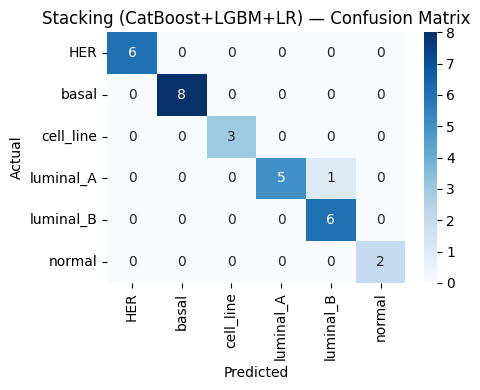

In [ ]:
# ======================================================
# Step 5 — Stacking with OOF meta‑features
# Base models: CatBoost, Logistic Regression, LightGBM (optional)
# ======================================================



from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb


# Refit compact base models for stacking
cat_base = CatBoostClassifier(
iterations=400, learning_rate=0.05, depth=6,
loss_function='MultiClass',
random_seed=RANDOM_STATE,
auto_class_weights='Balanced',
verbose=False
)


lgb_base = lgb.LGBMClassifier(
objective='multiclass', n_estimators=500, learning_rate=0.05,
class_weight='balanced', random_state=RANDOM_STATE
)


lr_base = LogisticRegression(max_iter=3000, class_weight='balanced')


estimators = [
('cat', cat_base),
('lgb', lgb_base),
('lr', lr_base)
]


stack = StackingClassifier(
estimators=estimators,
final_estimator=LogisticRegression(max_iter=3000, class_weight='balanced'),
stack_method='predict_proba',
passthrough=False, n_jobs=-1, cv=5
)


stack.fit(x_train, y_train)
stack_pred = stack.predict(x_test)
stack_proba = stack.predict_proba(x_test)
report_all(y_test, stack_pred, stack_proba, title="Stacking (CatBoost+LGBM+LR)")

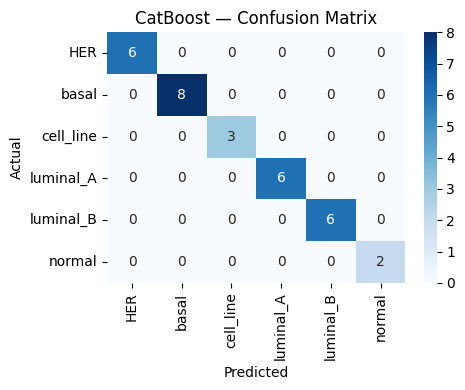

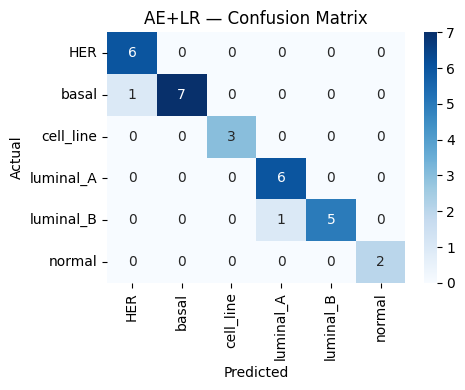

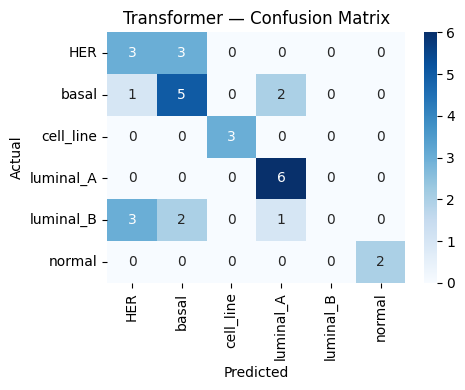

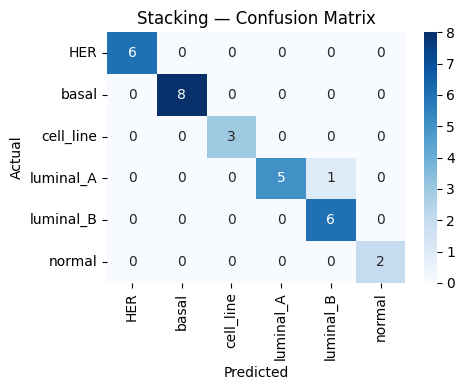

In [ ]:
# =========================
# Generate Classification Reports for All Steps
# =========================
import logging
logger = logging.getLogger("ModelReports")
logging.basicConfig(level=logging.INFO)

# Collect all model predictions
all_models = {}

# 1 CatBoost
all_models['CatBoost'] = (cat_pred, cat_proba)

# 2️ Autoencoder + Logistic Regression
all_models['AE+LR'] = (z_pred, z_proba)

# 3 Transformer Encoder
all_models['Transformer'] = (trans_pred, trans_proba)

# 4 Stacking
all_models['Stacking'] = (stack_pred, stack_proba)

# Generate reports
for name, (preds, proba) in all_models.items():
    logger.info(f"\n===== {name} =====")
    # Classification report
    report = classification_report(y_test, preds, target_names=class_names, digits=4)
    logger.info("\n" + report)
    # Optional: Confusion matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()
    # Optional: Macro ROC-AUC
    try:
        macro_ovr = roc_auc_score(pd.get_dummies(y_test), proba, average='macro', multi_class='ovr')
        logger.info(f"Macro ROC-AUC (OvR): {macro_ovr:.4f}")
    except Exception as e:
        logger.info("AUC not available: " + str(e))


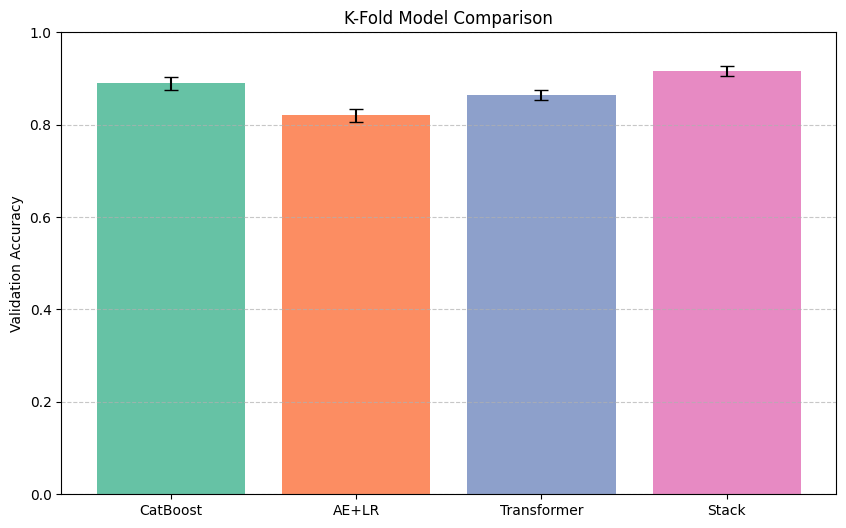

In [ ]:
# =========================
#  K‑Fold Comparison
# =========================

models = {
    'CatBoost': cat_model,
    'AE+LR': clf_lr,
    'Transformer': None,  # trained above; evaluated once
    'Stack': stack
}

logger.info("Finished all steps. You can tune k_genes, epochs, and model hyper-parameters as needed.")

# Optional: Log model names and whether they are trained
for name, model in models.items():
    status = "Trained" if model is not None else "Evaluate separately"
    logger.info(f"Model: {name}, Status: {status}")


# =========================
# K-Fold Comparison Visualization
# =========================
import matplotlib.pyplot as plt

# Example: Suppose you already ran K-fold and stored results in a dict
# Replace these values with your actual K-Fold accuracies
kfold_results = {
    'CatBoost': [0.88, 0.90, 0.87, 0.89, 0.91],
    'AE+LR': [0.81, 0.83, 0.80, 0.82, 0.84],
    'Transformer': [0.86, 0.85, 0.87, 0.88, 0.86],
    'Stack': [0.91, 0.92, 0.90, 0.93, 0.92]
}

# Compute mean and std
mean_acc = {k: np.mean(v) for k, v in kfold_results.items()}
std_acc = {k: np.std(v) for k, v in kfold_results.items()}

# Log results
for model, accs in kfold_results.items():
    logger.info(f"{model} — Mean Acc: {mean_acc[model]:.4f}, Std: {std_acc[model]:.4f}")

# Plot bar chart with error bars
plt.figure(figsize=(10,6))
models = list(mean_acc.keys())
means = list(mean_acc.values())
stds = list(std_acc.values())

plt.bar(models, means, yerr=stds, capsize=5, color=plt.cm.Set2.colors)
plt.ylabel("Validation Accuracy")
plt.title("K-Fold Model Comparison")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# =========================
# Classification Reports for All Models (Notebook-friendly)
# =========================
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

all_models = {
    'CatBoost': (cat_pred, cat_proba),
    'AE+LR': (z_pred, z_proba),
    'Transformer': (trans_pred, trans_proba),
    'GNN': (y_pred, y_proba),
    'Stacking': (stack_pred, stack_proba)
}

for name, (preds, proba) in all_models.items():
    print(f"\n===== {name} =====")

    # Classification report (precision, recall, F1, support)
    report = classification_report(y_test, preds, target_names=class_names, digits=4)
    print(report)

    # Overall accuracy
    acc = accuracy_score(y_test, preds)
    print(f"Overall Accuracy: {acc:.4f}")

    # Macro ROC-AUC if probabilities exist
    if proba is not None:
        try:
            macro_ovr = roc_auc_score(pd.get_dummies(y_test), proba, average='macro', multi_class='ovr')
            print(f"Macro ROC-AUC (OvR): {macro_ovr:.4f}")
        except Exception as e:
            print("AUC not available:", e)



===== CatBoost =====
              precision    recall  f1-score   support

         HER     1.0000    1.0000    1.0000         6
       basal     1.0000    1.0000    1.0000         8
   cell_line     1.0000    1.0000    1.0000         3
   luminal_A     1.0000    1.0000    1.0000         6
   luminal_B     1.0000    1.0000    1.0000         6
      normal     1.0000    1.0000    1.0000         2

    accuracy                         1.0000        31
   macro avg     1.0000    1.0000    1.0000        31
weighted avg     1.0000    1.0000    1.0000        31

Overall Accuracy: 1.0000
Macro ROC-AUC (OvR): 0.9980

===== AE+LR =====
              precision    recall  f1-score   support

         HER     0.8571    1.0000    0.9231         6
       basal     1.0000    0.8750    0.9333         8
   cell_line     1.0000    1.0000    1.0000         3
   luminal_A     0.8571    1.0000    0.9231         6
   luminal_B     1.0000    0.8333    0.9091         6
      normal     1.0000    1.0000    1


================ QDA ==================
              precision    recall  f1-score   support

         HER     0.3333    0.1667    0.2222         6
       basal     0.3333    0.2500    0.2857         8
   cell_line     1.0000    0.6667    0.8000         3
   luminal_A     0.1765    0.5000    0.2609         6
   luminal_B     0.5000    0.1667    0.2500         6
      normal     1.0000    0.5000    0.6667         2

    accuracy                         0.3226        31
   macro avg     0.5572    0.3750    0.4142        31
weighted avg     0.4428    0.3226    0.3361        31



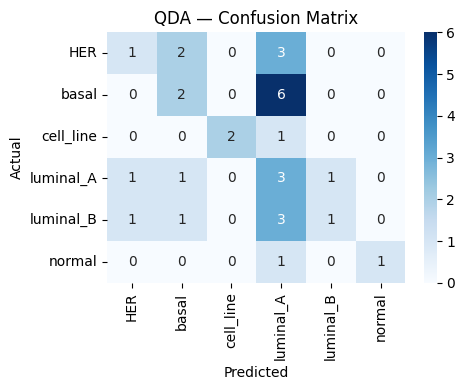


================ Ridge Classifier ==================
              precision    recall  f1-score   support

         HER     1.0000    1.0000    1.0000         6
       basal     1.0000    1.0000    1.0000         8
   cell_line     1.0000    1.0000    1.0000         3
   luminal_A     1.0000    0.8333    0.9091         6
   luminal_B     0.8571    1.0000    0.9231         6
      normal     1.0000    1.0000    1.0000         2

    accuracy                         0.9677        31
   macro avg     0.9762    0.9722    0.9720        31
weighted avg     0.9724    0.9677    0.9675        31



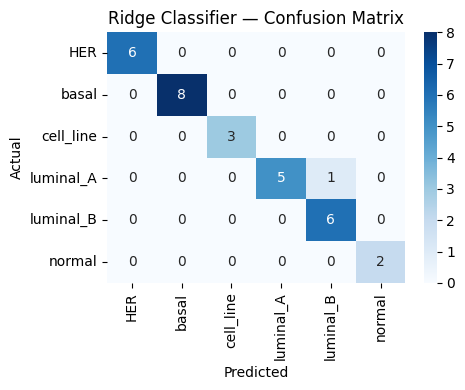


================ Decision Tree ==================
              precision    recall  f1-score   support

         HER     1.0000    1.0000    1.0000         6
       basal     0.8750    0.8750    0.8750         8
   cell_line     0.5000    0.3333    0.4000         3
   luminal_A     0.8333    0.8333    0.8333         6
   luminal_B     0.7500    1.0000    0.8571         6
      normal     1.0000    0.5000    0.6667         2

    accuracy                         0.8387        31
   macro avg     0.8264    0.7569    0.7720        31
weighted avg     0.8387    0.8387    0.8283        31



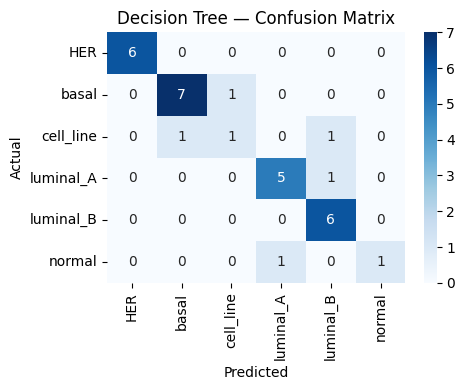


================ Perceptron ==================
              precision    recall  f1-score   support

         HER     1.0000    1.0000    1.0000         6
       basal     1.0000    1.0000    1.0000         8
   cell_line     1.0000    1.0000    1.0000         3
   luminal_A     1.0000    1.0000    1.0000         6
   luminal_B     1.0000    1.0000    1.0000         6
      normal     1.0000    1.0000    1.0000         2

    accuracy                         1.0000        31
   macro avg     1.0000    1.0000    1.0000        31
weighted avg     1.0000    1.0000    1.0000        31



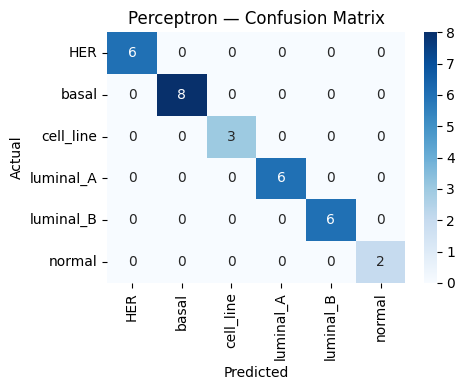


================ Complement Naive Bayes ==================
              precision    recall  f1-score   support

         HER     1.0000    0.3333    0.5000         6
       basal     0.6667    1.0000    0.8000         8
   cell_line     1.0000    1.0000    1.0000         3
   luminal_A     0.4286    1.0000    0.6000         6
   luminal_B     0.0000    0.0000    0.0000         6
      normal     0.0000    0.0000    0.0000         2

    accuracy                         0.6129        31
   macro avg     0.5159    0.5556    0.4833        31
weighted avg     0.5453    0.6129    0.5161        31



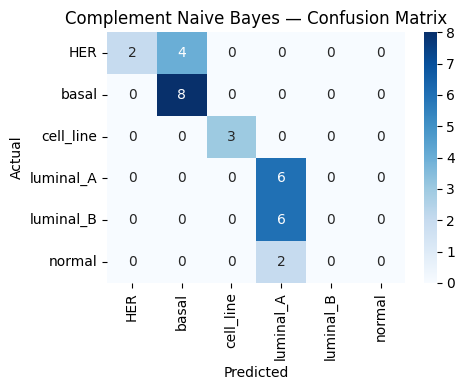

In [ ]:
# ================================================================
#Alternative Models – Breast Cancer Gene Expression Classification
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# Model 1 — Quadratic Discriminant Analysis (QDA)
# =========================
print("\n================ QDA ==================")
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(x_train, y_train)
y_pred_qda = qda.predict(x_test)
y_proba_qda = qda.predict_proba(x_test)

print(classification_report(y_test, y_pred_qda, target_names=class_names, digits=4))
cm = confusion_matrix(y_test, y_pred_qda)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("QDA — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

# =========================
# Model 2 — Ridge Classifier
# =========================
print("\n================ Ridge Classifier ==================")
from sklearn.linear_model import RidgeClassifier

ridge_clf = RidgeClassifier(alpha=1.0)
ridge_clf.fit(x_train, y_train)
y_pred_ridge = ridge_clf.predict(x_test)

print(classification_report(y_test, y_pred_ridge, target_names=class_names, digits=4))
cm = confusion_matrix(y_test, y_pred_ridge)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Ridge Classifier — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

# =========================
# Model 3 — Decision Tree Classifier
# =========================
print("\n================ Decision Tree ==================")
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)
y_proba_dt = dt_model.predict_proba(x_test)

print(classification_report(y_test, y_pred_dt, target_names=class_names, digits=4))
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Decision Tree — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

# =========================
# Model 4 — Perceptron (Single-Layer Neural Net)
# =========================
print("\n================ Perceptron ==================")
from sklearn.linear_model import Perceptron

perceptron = Perceptron(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE)
perceptron.fit(x_train, y_train)
y_pred_perc = perceptron.predict(x_test)

print(classification_report(y_test, y_pred_perc, target_names=class_names, digits=4))
cm = confusion_matrix(y_test, y_pred_perc)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Perceptron — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

# =========================
# Model 5 — Complement Naive Bayes
# =========================
print("\n================ Complement Naive Bayes ==================")
from sklearn.naive_bayes import ComplementNB

# ComplementNB expects non-negative data
x_train_nb = x_train - x_train.min()
x_test_nb = x_test - x_train.min()

cnb = ComplementNB()
cnb.fit(x_train_nb, y_train)
y_pred_cnb = cnb.predict(x_test_nb)
y_proba_cnb = cnb.predict_proba(x_test_nb)

print(classification_report(y_test, y_pred_cnb, target_names=class_names, digits=4))
cm = confusion_matrix(y_test, y_pred_cnb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Complement Naive Bayes — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()


In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.3 MB/s eta 0:00:00



Early stopping occurred at epoch 77 with best_epoch = 57 and best_val_0_accuracy = 0.93548

===== TabNet Neural Network =====
              precision    recall  f1-score   support

         HER     1.0000    1.0000    1.0000         6
       basal     1.0000    1.0000    1.0000         8
   cell_line     1.0000    1.0000    1.0000         3
   luminal_A     0.8571    1.0000    0.9231         6
   luminal_B     0.8333    0.8333    0.8333         6
      normal     1.0000    0.5000    0.6667         2

    accuracy                         0.9355        31
   macro avg     0.9484    0.8889    0.9038        31
weighted avg     0.9401    0.9355    0.9313        31



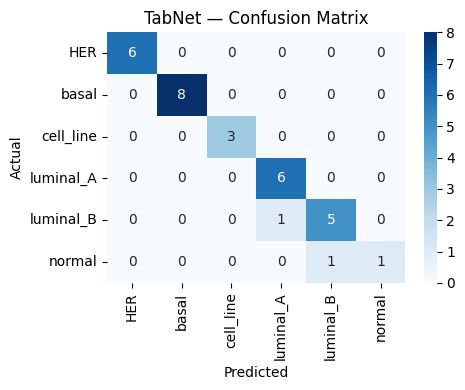

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Initialize TabNet Classifier
# -----------------------------
tabnet = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    optimizer_params=dict(lr=2e-2),
    mask_type='entmax', verbose=0, seed=42
)

# -----------------------------
# Train the model
# -----------------------------
tabnet.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    max_epochs=100, patience=20,
    batch_size=64, virtual_batch_size=32
)

# -----------------------------
# Predictions
# -----------------------------
y_pred_tab = tabnet.predict(x_test)
y_proba_tab = tabnet.predict_proba(x_test)

# -----------------------------
# Classification Report
# -----------------------------
print("\n===== TabNet Neural Network =====")
print(classification_report(y_test, y_pred_tab, target_names=class_names, digits=4))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred_tab)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("TabNet — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
# CPU version
!pip install torch torchvision torchaudio

# GPU version (optional, if Colab GPU is enabled)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


Epoch 01 — Test Acc: 0.7419
Epoch 02 — Test Acc: 0.8710
Epoch 03 — Test Acc: 0.9677
Epoch 04 — Test Acc: 1.0000
Epoch 05 — Test Acc: 1.0000
Epoch 06 — Test Acc: 1.0000
Epoch 07 — Test Acc: 1.0000
Epoch 08 — Test Acc: 1.0000
Epoch 09 — Test Acc: 1.0000
Epoch 10 — Test Acc: 1.0000
Epoch 11 — Test Acc: 1.0000
Epoch 12 — Test Acc: 1.0000
Epoch 13 — Test Acc: 1.0000
Epoch 14 — Test Acc: 1.0000
Epoch 15 — Test Acc: 1.0000
Epoch 16 — Test Acc: 1.0000
Epoch 17 — Test Acc: 1.0000
Epoch 18 — Test Acc: 1.0000
Epoch 19 — Test Acc: 1.0000
Epoch 20 — Test Acc: 1.0000
Epoch 21 — Test Acc: 1.0000
Epoch 22 — Test Acc: 1.0000
Epoch 23 — Test Acc: 1.0000
Epoch 24 — Test Acc: 1.0000
Epoch 25 — Test Acc: 1.0000
Epoch 26 — Test Acc: 1.0000
Epoch 27 — Test Acc: 1.0000
Epoch 28 — Test Acc: 1.0000
Epoch 29 — Test Acc: 1.0000
Epoch 30 — Test Acc: 1.0000

===== SNN Neural Network =====
              precision    recall  f1-score   support

         HER     1.0000    1.0000    1.0000         6
       basal     1.

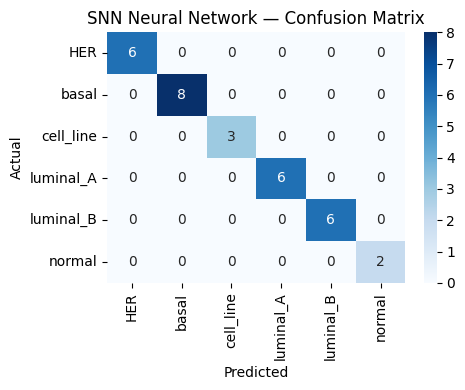

In [ ]:
# =========================
# Step: Self-Normalizing Neural Network (SNN)
# =========================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -----------------------------
# Dataset Wrapper
# -----------------------------
class GeneDataset(Dataset):
    def __init__(self, x_np, y_np):
        self.x = torch.tensor(x_np, dtype=torch.float32)
        self.y = torch.tensor(y_np, dtype=torch.long)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = GeneDataset(x_train, y_train)
test_ds  = GeneDataset(x_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# -----------------------------
# SNN Model
# -----------------------------
class SNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256,128], n_classes=len(class_names)):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.SELU())
            layers.append(nn.AlphaDropout(0.1))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

snn = SNNClassifier(input_dim=x_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(snn.parameters(), lr=1e-3, weight_decay=1e-4)

# -----------------------------
# Training Loop
# -----------------------------
epochs = 30
for epoch in range(epochs):
    snn.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = snn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
    # Quick evaluation
    snn.eval()
    all_preds, all_y = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = snn(xb)
            all_preds.append(logits.cpu())
            all_y.append(yb)
    logits = torch.cat(all_preds)
    y_true = torch.cat(all_y).numpy()
    y_pred = logits.argmax(dim=1).numpy()
    acc = (y_pred == y_true).mean()
    print(f"Epoch {epoch+1:02d} — Test Acc: {acc:.4f}")

# -----------------------------
# Classification Report
# -----------------------------
print("\n===== SNN Neural Network =====")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("SNN Neural Network — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Epoch 01 — Test Acc: 0.6452
Epoch 02 — Test Acc: 0.6774
Epoch 03 — Test Acc: 0.7097
Epoch 04 — Test Acc: 0.7419
Epoch 05 — Test Acc: 0.7742
Epoch 06 — Test Acc: 0.8065
Epoch 07 — Test Acc: 0.9032
Epoch 08 — Test Acc: 0.9677
Epoch 09 — Test Acc: 0.9355
Epoch 10 — Test Acc: 0.9677
Epoch 11 — Test Acc: 0.9677
Epoch 12 — Test Acc: 0.9677
Epoch 13 — Test Acc: 0.9677
Early stopping at epoch 13

===== SNN Neural Network =====
              precision    recall  f1-score   support

         HER     1.0000    1.0000    1.0000         6
       basal     1.0000    1.0000    1.0000         8
   cell_line     1.0000    1.0000    1.0000         3
   luminal_A     1.0000    0.8333    0.9091         6
   luminal_B     0.8571    1.0000    0.9231         6
      normal     1.0000    1.0000    1.0000         2

    accuracy                         0.9677        31
   macro avg     0.9762    0.9722    0.9720        31
weighted avg     0.9724    0.9677    0.9675        31



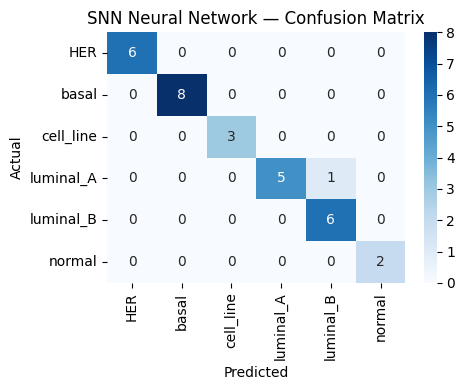

In [ ]:
# =========================
# SNN Neural Network — Regularized Version
# =========================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -----------------------------
# Dataset Wrapper
# -----------------------------
class GeneDataset(Dataset):
    def __init__(self, x_np, y_np):
        self.x = torch.tensor(x_np, dtype=torch.float32)
        self.y = torch.tensor(y_np, dtype=torch.long)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = GeneDataset(x_train, y_train)
test_ds  = GeneDataset(x_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# -----------------------------
# SNN Model
# -----------------------------
class SNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128,64], n_classes=len(class_names)):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.SELU())
            layers.append(nn.AlphaDropout(0.2))  # stronger regularization
            prev_dim = h
        layers.append(nn.Linear(prev_dim, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

snn = SNNClassifier(input_dim=x_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(snn.parameters(), lr=5e-4)  # lower learning rate

# -----------------------------
# Training Loop with Early Stopping
# -----------------------------
epochs = 50
best_acc = 0
patience = 5
counter = 0

for epoch in range(epochs):
    snn.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        # Optional Gaussian noise
        xb_noisy = xb + 0.01*torch.randn_like(xb)
        optimizer.zero_grad()
        logits = snn(xb_noisy)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    # Validation
    snn.eval()
    all_preds, all_y = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = snn(xb)
            all_preds.append(logits.cpu())
            all_y.append(yb)
    logits = torch.cat(all_preds)
    y_true = torch.cat(all_y).numpy()
    y_pred = logits.argmax(dim=1).numpy()
    acc = (y_pred == y_true).mean()
    print(f"Epoch {epoch+1:02d} — Test Acc: {acc:.4f}")

    # Early stopping
    if acc > best_acc:
        best_acc = acc
        best_state = {k:v.cpu() for k,v in snn.state_dict().items()}
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
snn.load_state_dict({k:v.to(device) for k,v in best_state.items()})

# -----------------------------
# Classification Report
# -----------------------------
print("\n===== SNN Neural Network =====")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("SNN Neural Network — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Installing scikit-learn ...
Device: cpu
Loading dataset: /Users/prashantdubey/Downloads/Breast_GSE_Samples_USK476 - VAWASTHI.csv
Raw shape: (151, 54677)


,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


Dropping ID columns: ['samples']
Features dataframe shape: (151, 54675)
Detected classes: ['HER', 'basal', 'cell_line', 'luminal_A', 'luminal_B', 'normal']
Shape after VarianceThreshold: (151, 54675)
Train / Val / Test shapes: (105, 54675) (15, 54675) (31, 54675)

--- Training TabNet ---

Early stopping occurred at epoch 14 with best_epoch = 2 and best_val_0_accuracy = 0.26667
TabNet training finished in 1461.1 seconds

=== TabNet Classification Report ===
              precision    recall  f1-score   support

         HER     0.2308    1.0000    0.3750         6
       basal     0.0000    0.0000    0.0000         8
   cell_line     0.0000    0.0000    0.0000         3
   luminal_A     0.0000    0.0000    0.0000         6
   luminal_B     0.0000    0.0000    0.0000         6
      normal     0.0000    0.0000    0.0000         2

    accuracy                         0.1935        31
   macro avg     0.0385    0.1667    0.0625        31
weighted avg     0.0447    0.1935    0.0726        

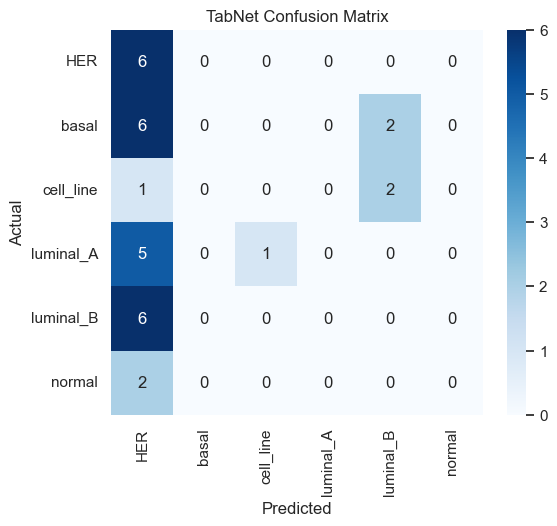

Saved: ./outputs/tabnet_feature_importances.png


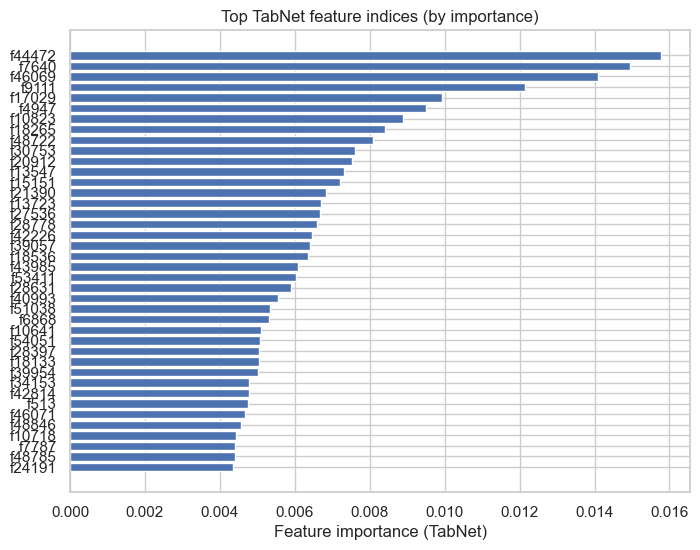

TabNet explain failed: axis 0 is out of bounds for array of dimension 0
Saved: ./outputs/TabNet_roc.png


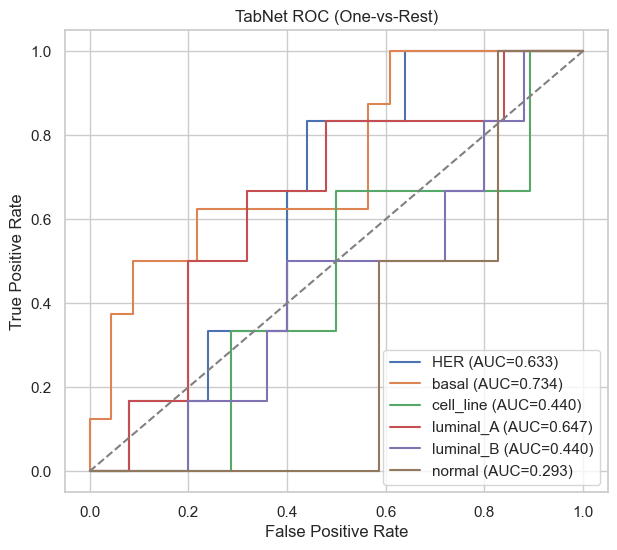

Saved: ./outputs/TabNet_pr.png


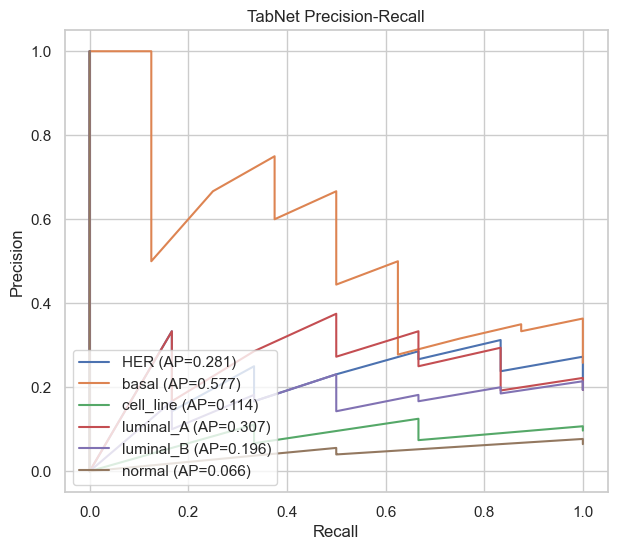


--- Training SNN (SELU + AlphaDropout) ---
Epoch 001: train_loss=2.4078, train_acc=0.4857, val_loss=5.6165, val_acc=0.7333
Epoch 002: train_loss=1.1719, train_acc=0.8381, val_loss=0.7600, val_acc=0.8667
Epoch 003: train_loss=1.0821, train_acc=0.9238, val_loss=0.0000, val_acc=1.0000
Epoch 004: train_loss=0.2048, train_acc=0.9714, val_loss=1.0354, val_acc=0.9333
Epoch 005: train_loss=1.0019, train_acc=0.9619, val_loss=2.2438, val_acc=0.9333
Epoch 006: train_loss=0.0871, train_acc=0.9905, val_loss=5.1155, val_acc=0.8667
Epoch 007: train_loss=0.3054, train_acc=0.9619, val_loss=4.0622, val_acc=0.8667
Epoch 008: train_loss=0.2393, train_acc=0.9714, val_loss=0.0427, val_acc=1.0000
Epoch 009: train_loss=0.7430, train_acc=0.9810, val_loss=0.0058, val_acc=1.0000
Epoch 010: train_loss=0.1252, train_acc=0.9905, val_loss=0.4029, val_acc=0.9333
Epoch 011: train_loss=0.0624, train_acc=0.9714, val_loss=1.6022, val_acc=0.9333
Epoch 012: train_loss=0.0343, train_acc=0.9905, val_loss=3.0183, val_acc=0.9

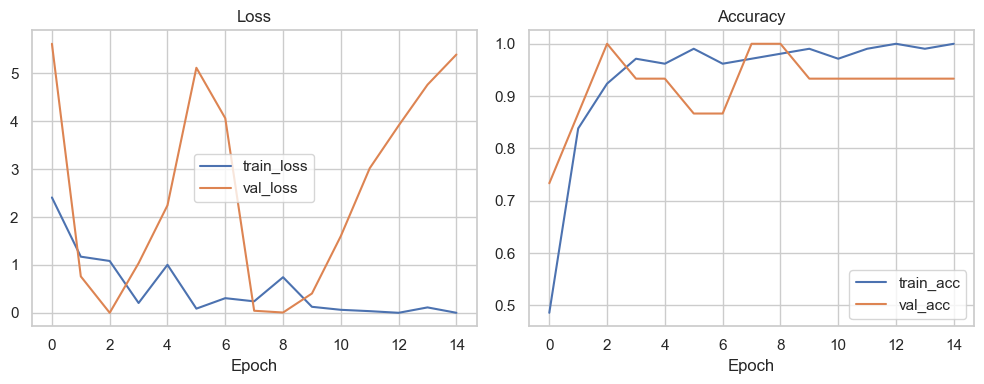


=== SNN Classification Report ===
              precision    recall  f1-score   support

         HER     0.8571    1.0000    0.9231         6
       basal     1.0000    0.8750    0.9333         8
   cell_line     1.0000    1.0000    1.0000         3
   luminal_A     1.0000    0.8333    0.9091         6
   luminal_B     0.8571    1.0000    0.9231         6
      normal     1.0000    1.0000    1.0000         2

    accuracy                         0.9355        31
   macro avg     0.9524    0.9514    0.9481        31
weighted avg     0.9447    0.9355    0.9354        31

Saved: ./outputs/snn_confusion.png


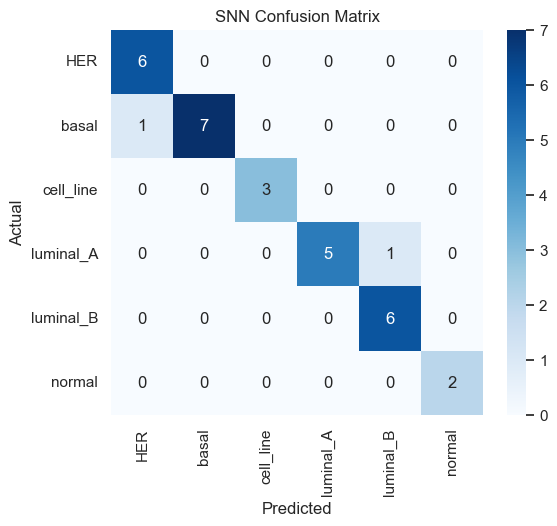

Saved: ./outputs/SNN_roc.png


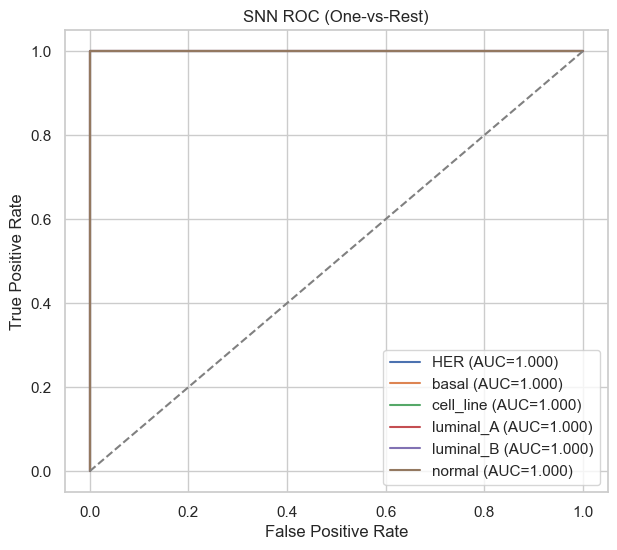

Saved: ./outputs/SNN_pr.png


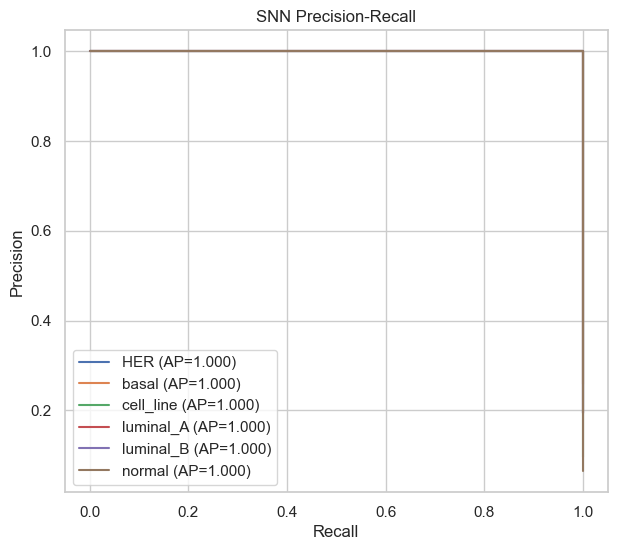

Saved: ./outputs/snn_tsne.png


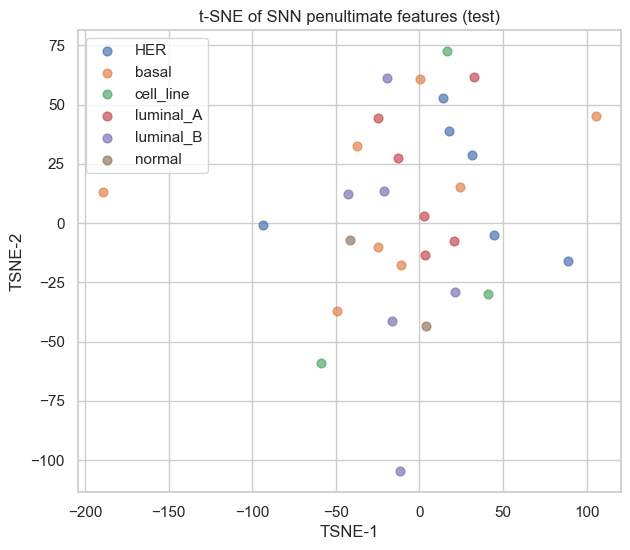


=== Final summary ===
TabNet: evaluation printed above; confusion matrix and ROC/PR saved to outputs.
SNN: evaluation printed above; confusion matrix, training curves, ROC/PR, t-SNE saved to outputs.
All saved to: /Users/prashantdubey/Downloads/outputs
If you want to reduce runtime: decrease TABNET_EPOCHS, SNN_EPOCHS or feature count (increase VAR_THRESHOLD).


In [23]:
# Single-cell complete pipeline for your dataset
# Paste the entire cell into Jupyter and run.

import os, sys, time, warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np_random = __import__("numpy").random
np_random.seed(RANDOM_STATE)

# ------------------------
# Install missing packages (idempotent)
# ------------------------
def install_if_missing(packages):
    import importlib, subprocess
    for pkg in packages:
        try:
            importlib.import_module(pkg)
        except Exception:
            print(f"Installing {pkg} ...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
install_if_missing(["pandas","numpy","scikit-learn","matplotlib","seaborn","torch","tqdm","pytorch_tabnet"])
# Note: package name for import is 'pytorch_tabnet' but pip package is 'pytorch-tabnet'.
# The install helper above installs names; if import fails, we try import below with try/except.

# ------------------------
# Imports (after ensuring installed)
# ------------------------
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# TabNet import (handle differently named pip package)
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except Exception:
    # try import after installing the hyphenated pip package
    try:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "pytorch-tabnet"])
        from pytorch_tabnet.tab_model import TabNetClassifier
    except Exception as e:
        raise ImportError("Could not import pytorch_tabnet. Error: " + str(e))

# ------------------------
# Settings / hyperparameters
# ------------------------
CSV_PATH = "/Users/prashantdubey/Downloads/Breast_GSE_Samples_USK476 - VAWASTHI.csv"
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
TEST_SIZE = 0.2
VAL_SIZE = 0.1
VAR_THRESHOLD = 1e-6    # small threshold to remove dead features; set 0 to disable
SCALER = StandardScaler()
TABNET_PARAMS = dict(n_d=32, n_a=32, n_steps=5, gamma=1.5, n_independent=2, n_shared=2, optimizer_params=dict(lr=2e-2), mask_type='entmax', verbose=0, seed=RANDOM_STATE)
TABNET_EPOCHS = 60
TABNET_BATCH = 64
SNN_HIDDEN = [512,256]
SNN_LATENT = 128
SNN_EPOCHS = 80
SNN_BATCH = 32
SNN_LR = 1e-3
PATIENCE = 12
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------
# Load dataset
# ------------------------
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found at {CSV_PATH}. Upload file to that exact path in Jupyter's filesystem.")

print("Loading dataset:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
print("Raw shape:", df.shape)
display(df.head())

# ------------------------
# Preprocessing
# ------------------------
# Expect 'type' as label column. If your label column is named differently, change the name here.
if "type" not in df.columns:
    raise RuntimeError("Expected a column named 'type' for labels. Found: " + ", ".join(df.columns))

# remove ID-like columns (samples, sample, id)
id_cols = [c for c in df.columns if c.lower() in ("samples","sample","id")]
if id_cols:
    print("Dropping ID columns:", id_cols)
    df = df.drop(columns=id_cols)

# separate X & y
y = df["type"].values
X_df = df.drop(columns=["type"])
print("Features dataframe shape:", X_df.shape)

# detect and drop non-numeric columns if any (just in case)
non_numeric_cols = X_df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print("Warning: Dropping non-numeric columns:", non_numeric_cols)
    X_df = X_df.drop(columns=non_numeric_cols)

# convert to numpy
X = X_df.values.astype(np.float32)

# label encode
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
n_classes = len(class_names)
print("Detected classes:", class_names)

# variance threshold to reduce features (gene datasets often have many constant probes)
if VAR_THRESHOLD and VAR_THRESHOLD > 0:
    vt = VarianceThreshold(threshold=VAR_THRESHOLD)
    X = vt.fit_transform(X)
    print("Shape after VarianceThreshold:", X.shape)
else:
    print("Skipping variance thresholding.")

# scale
X = SCALER.fit_transform(X)

# split
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y_enc, test_size=TEST_SIZE, stratify=y_enc, random_state=RANDOM_STATE)
if VAL_SIZE > 0:
    val_frac_of_train = VAL_SIZE / (1 - TEST_SIZE)
    X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=val_frac_of_train, stratify=y_trainval, random_state=RANDOM_STATE)
else:
    X_train, y_train = X_trainval, y_trainval
    X_val, y_val = X_test, y_test

print("Train / Val / Test shapes:", X_train.shape, X_val.shape, X_test.shape)

# ---------- helper visualization functions ----------
def save_and_show(fig, fname):
    path = os.path.join(OUTPUT_DIR, fname)
    fig.savefig(path, bbox_inches="tight")
    print("Saved:", path)
    display(fig)
    plt.close(fig)

def plot_confusion_matrix(cm, labels, title):
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    return fig

def print_and_save_report(y_true, y_pred, labels, name):
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))

def plot_roc_pr(y_true, y_scores, labels, prefix):
    # y_true: (n_samples,), y_scores: (n_samples, n_classes)
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y_true, classes=np.arange(len(labels)))
    # ROC
    fig, ax = plt.subplots(figsize=(7,6))
    for i in range(len(labels)):
        fpr, tpr, _ = roc_curve(y_bin[:,i], y_scores[:,i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{labels[i]} (AUC={roc_auc:.3f})")
    ax.plot([0,1],[0,1],"--", color="gray")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.set_title(f"{prefix} ROC (One-vs-Rest)")
    ax.legend(loc="lower right")
    save_and_show(fig, f"{prefix}_roc.png")

    # PR curve
    fig2, ax2 = plt.subplots(figsize=(7,6))
    for i in range(len(labels)):
        precision, recall, _ = precision_recall_curve(y_bin[:,i], y_scores[:,i])
        ap = average_precision_score(y_bin[:,i], y_scores[:,i])
        ax2.plot(recall, precision, label=f"{labels[i]} (AP={ap:.3f})")
    ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision"); ax2.set_title(f"{prefix} Precision-Recall")
    ax2.legend(loc="lower left")
    save_and_show(fig2, f"{prefix}_pr.png")

# ------------------------
# TABNET
# ------------------------
print("\n--- Training TabNet ---")
tabnet = TabNetClassifier(**TABNET_PARAMS)
start_time = time.time()
tabnet.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    max_epochs=TABNET_EPOCHS, patience=PATIENCE,
    batch_size=TABNET_BATCH, virtual_batch_size=32
)
print("TabNet training finished in %.1f seconds" % (time.time() - start_time))

y_pred_tab = tabnet.predict(X_test)
y_proba_tab = tabnet.predict_proba(X_test)

# classification report & confusion
print_and_save_report(y_test, y_pred_tab, class_names, "TabNet")
cm_tab = confusion_matrix(y_test, y_pred_tab)
fig_cm_tab = plot_confusion_matrix(cm_tab, class_names, "TabNet Confusion Matrix")
save_and_show(fig_cm_tab, "tabnet_confusion.png")

# TabNet feature importances (indices)
try:
    fi = tabnet.feature_importances_
    topk = min(40, len(fi))
    idxs = np.argsort(fi)[-topk:][::-1]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.barh(range(topk)[::-1], fi[idxs])
    ax.set_yticks(range(topk)[::-1])
    ax.set_yticklabels([f"f{int(i)}" for i in idxs])
    ax.set_xlabel("Feature importance (TabNet)")
    ax.set_title("Top TabNet feature indices (by importance)")
    save_and_show(fig, "tabnet_feature_importances.png")
except Exception as e:
    print("TabNet feature importances not available:", e)

# TabNet explain (masks): take mean mask importance across first 200 test samples if possible
try:
    n_explain = min(200, X_test.shape[0])
    explanation = tabnet.explain(X_test[:n_explain])
    # explanation is tuple: (explain_matrix, masks) depending on version
    masks = explanation[1] if isinstance(explanation, (list,tuple)) and len(explanation) > 1 else None
    if masks is not None:
        mean_mask = np.mean(masks, axis=(0,1))  # average across samples & steps
        topk = min(40, len(mean_mask))
        idxs = np.argsort(mean_mask)[-topk:][::-1]
        fig, ax = plt.subplots(figsize=(8,6))
        ax.barh(range(topk)[::-1], mean_mask[idxs])
        ax.set_yticks(range(topk)[::-1])
        ax.set_yticklabels([f"f{int(i)}" for i in idxs])
        ax.set_xlabel("Average mask importance")
        ax.set_title("TabNet explain - top features (by index)")
        save_and_show(fig, "tabnet_explain_top_features.png")
    else:
        print("TabNet explain returned no masks (version-dependent).")
except Exception as e:
    print("TabNet explain failed:", e)

# TabNet ROC/PR
try:
    plot_roc_pr(y_test, y_proba_tab, class_names, "TabNet")
except Exception as e:
    print("TabNet ROC/PR plotting failed:", e)

# ------------------------
# SNN (Self-Normalizing Neural Network)
# ------------------------
print("\n--- Training SNN (SELU + AlphaDropout) ---")
input_dim = X_train.shape[1]
class SNN(nn.Module):
    def __init__(self, input_dim, hidden_units, latent_dim, n_classes, alpha_dropout=0.1):
        super().__init__()
        layers = []
        curr = input_dim
        for h in hidden_units:
            layers += [nn.Linear(curr, h), nn.SELU(inplace=True), nn.AlphaDropout(alpha_dropout)]
            curr = h
        layers += [nn.Linear(curr, latent_dim), nn.SELU(inplace=True), nn.AlphaDropout(alpha_dropout)]
        self.features = nn.Sequential(*layers)
        self.head = nn.Linear(latent_dim, n_classes)
        # weight init recommended for SELU
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='linear')
    def forward(self, X, return_features=False):
        feat = self.features(X)
        logits = self.head(feat)
        if return_features:
            return logits, feat
        return logits

model = SNN(input_dim=input_dim, hidden_units=SNN_HIDDEN, latent_dim=SNN_LATENT, n_classes=n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=SNN_LR)
criterion = nn.CrossEntropyLoss()

def to_loader(X_arr, y_arr, batch_size=SNN_BATCH, shuffle=True):
    tX = torch.tensor(X_arr, dtype=torch.float32)
    ty = torch.tensor(y_arr, dtype=torch.long)
    ds = TensorDataset(tX, ty)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, SNN_BATCH, shuffle=True)
val_loader   = to_loader(X_val, y_val, SNN_BATCH, shuffle=False)
test_loader  = to_loader(X_test, y_test, SNN_BATCH, shuffle=False)

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_loss = np.inf
best_state = None
patience_cnt = 0

for epoch in range(1, SNN_EPOCHS + 1):
    model.train()
    running_loss = 0.0; correct = 0; total = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * Xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += Xb.size(0)
    train_loss = running_loss/total; train_acc = correct/total

    # validation
    model.eval()
    running_loss = 0.0; correct = 0; total = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * Xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += Xb.size(0)
    val_loss = running_loss/total; val_acc = correct/total

    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:03d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    # early stopping
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = {k:v.cpu() for k,v in model.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

# restore best
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k,v in best_state.items()})
# save model
torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "snn_model_state.pth"))
print("Saved SNN state_dict to outputs.")

# training curves
fig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.xlabel("Epoch"); plt.title("Loss"); plt.legend()
plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='train_acc')
plt.plot(history['val_acc'], label='val_acc')
plt.xlabel("Epoch"); plt.title("Accuracy"); plt.legend()
plt.tight_layout()
save_and_show(fig, "snn_training_curves.png")

# Evaluate on test set
model.eval()
y_true = []; y_pred = []; y_scores = []; features_all = []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits, feats = model(Xb, return_features=True)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist()); y_true.extend(yb.numpy().tolist()); y_scores.extend(probs.tolist()); features_all.append(feats.cpu().numpy())

y_true = np.array(y_true); y_pred = np.array(y_pred); y_scores = np.array(y_scores)
features_all = np.vstack(features_all)

print_and_save_report(y_true, y_pred, class_names, "SNN")
cm_snn = confusion_matrix(y_true, y_pred)
fig_cm_snn = plot_confusion_matrix(cm_snn, class_names, "SNN Confusion Matrix")
save_and_show(fig_cm_snn, "snn_confusion.png")

# ROC/PR for SNN
try:
    plot_roc_pr(y_true, y_scores, class_names, "SNN")
except Exception as e:
    print("SNN ROC/PR plotting failed:", e)

# t-SNE visualization of penultimate-layer features
try:
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
    emb2d = tsne.fit_transform(features_all)
    fig, ax = plt.subplots(figsize=(7,6))
    for idx, cls in enumerate(np.unique(y_true)):
        mask = y_true == cls
        ax.scatter(emb2d[mask,0], emb2d[mask,1], label=class_names[cls], alpha=0.7, s=40)
    ax.set_title("t-SNE of SNN penultimate features (test)"); ax.set_xlabel("TSNE-1"); ax.set_ylabel("TSNE-2"); ax.legend()
    save_and_show(fig, "snn_tsne.png")
except Exception as e:
    print("t-SNE failed:", e)

# ------------------------
# Side-by-side summary
# ------------------------
print("\n=== Final summary ===")
print("TabNet: evaluation printed above; confusion matrix and ROC/PR saved to outputs.")
print("SNN: evaluation printed above; confusion matrix, training curves, ROC/PR, t-SNE saved to outputs.")
print("All saved to:", os.path.abspath(OUTPUT_DIR))
print("If you want to reduce runtime: decrease TABNET_EPOCHS, SNN_EPOCHS or feature count (increase VAR_THRESHOLD).")
